In [1]:
import os
os.environ["OMP_NUM_THREADS"] = "1"
print(os.cpu_count())

144


In [2]:
import numpy as np
import math
import random as rand
import statistics
import matplotlib.pyplot as plt
from tqdm import tqdm

from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

# Grid search with cross validation

From `num` data points (which is the dimension of `y`), `num_train` training data points and `num_test` testing data points are randomly selected.

Then, cross-validation is performed on the training data to determine the optimal hyperparameters. `kfold` specifies the number of folds for cross-validation, and `ite` specifies the number of repetitions for cross-validation.

The hyperparameters to be optimized are the regularization parameter (candidate values are stored in `alpha_list`) and the kernel's own hyperparameters (a list of Gram matrices with different hyperparameters is stored in `G0_list`).

Afterward, the training data is used to train the model with the optimal hyperparameters, and the prediction accuracy is output for the test data. This entire procedure is repeated `rep` times, and the mean and standard deviation of the accuracy are output.

- `num_train`: Number of training data points.
- `num_test`: Number of testing data points.
- `G0_list`: A list of Gram matrices. Each element corresponds to a Gram matrix with different hyperparameters. The optimal one will be selected from this list.
- `y`: Label vector.
- `kfold`: Number of folds for cross-validation.
- `ite`: Number of repetitions for cross-validation.
- `rep`: Number of repetitions for the entire procedure.
- `seed`: Random seed.
- `alpha_list`: List of regularization parameter candidates.

In [3]:
def calculate_pred_acc(G0_list, y, kfold, ite, rep, seed, alpha_list):
    rand.seed(seed)
    num = len(y)
    
    fin_acc_list = []
    # # The calculation of accuracy is repeated `rep` times, varying the training and test data each time, to determine the average accuracy.
    # for _ in range(rep):   
    #     a = [i for i in range(num)]
    #     rand.shuffle(a)
    #     train_list = sorted(a[0:num_train], key=abs)
    #     test_list = sorted(a[num_train:num_train+num_test], key=abs)

    #     ## Determine optimal alpha and hyperparameters
    #     G0,alpha = optimize_hyperparameters(train_list, test_list, G0_list, y, kfold, ite, alpha_list)
        
    #     ## Perform SVM with oprimal G0 to calculate accuracy
    #     G_train, G_test, y_train, y_test = divide_data(G0, y, train_list, test_list)
    #     svm = SVC(kernel="precomputed", C=alpha)
    #     svm.fit(G_train, y_train)
    #     ptest = svm.predict(G_test)
    #     fin_acc = accuracy_score(y_test, ptest)
    #     fin_acc_list.append(fin_acc)
   
    for _ in range(rep):
        a = [i for i in range(num)]
        train_list = a[40*4:40*4+40] + a[40*14:40*14+40] 
        del a[20*14:20*14+20]
        test_list = a

        ## Determine optimal alpha and hyperparameters
        G0,alpha = optimize_hyperparameters(train_list, test_list, G0_list, y, kfold, ite, alpha_list)
        
        ## Perform SVM with oprimal G0 to calculate accuracy
        G_train, G_test, y_train, y_test = divide_data(G0, y, train_list, test_list)
        svm = SVC(kernel="precomputed", C=alpha)
        svm.fit(G_train, y_train)
        ptest = svm.predict(G_test)
        fin_acc = accuracy_score(y_test, ptest)
        fin_acc_list.append(fin_acc)
    
    # Calculate mean and standard dev over rep results
    if rep==1:
        mean = fin_acc_list[0]
        stdv = 0.0
    else:
        mean = statistics.mean(fin_acc_list)
        stdv = statistics.stdev(fin_acc_list)
        
    #print(f"fin_acc_list = {fin_acc_list}")
    print(f"mean = {mean}, stdv = {stdv}")
    print(f"----------------------------")
    
    return mean, stdv

Perform grid search on the training data `train_list` using cross-validation to optimize hyperparameters.

- `train_list`: List of training data.
- `test_list`: List of testing data.
- `G0_list`: List of Gram matrices.
- `y`: Label vector.
- `kfold`: Number of splits for cross-validation.
- `ite`: Number of repetitions for cross-validation.
- `alpha_list`: List of candidate regularization parameters.

In [4]:
def optimize_hyperparameters(train_list, test_list, G0_list, y, kfold, ite, alpha_list):
    ## Determine optimal alpha and hyperparameters
    alpha_cand = []
    acc_cand = []
    ### Optimize alpha for each G0
    for G0 in G0_list:
        # From `num` data points, `num_train` training data points and `num_test` testing data points are extracted.
        G_train, G_test, y_train, y_test = divide_data(G0, y, train_list, test_list)
        alpha, acc = grid_search_SVM(kfold, ite, G_train, y_train, alpha_list)
        alpha_cand.append(alpha)
        acc_cand.append(acc)

    ### Find optimal G0
    index = np.argmax(acc_cand)
    alpha = alpha_cand[index]
    G0 = G0_list[index]
    
    return G0, alpha

Extract sub-matrices of the Gram matrix `G0` and label vector `y` corresponding to the training data `train_list` and test data `test_list`.

- `G0`: Gram matrix.
- `y`: Label vector.
- `train_list`: List of training data indices.
- `test_list`: List of testing data indices.

In [5]:
def divide_data(G0, y, train_list, test_list):
    
    G_train = np.take(G0, train_list, axis=0)
    G_train = np.take(G_train, train_list, axis=1)
    
    G_test = np.take(G0, test_list, axis=0)
    G_test = np.take(G_test, train_list, axis=1)
    
    y_train = np.take(y, train_list, axis=0)
    y_test = np.take(y, test_list, axis=0)
    
    return G_train, G_test, y_train, y_test

Perform a grid search for the regularization parameter `alpha` from `alpha_list`.

For each `alpha` value, `k-fold` cross-validation (where `k=kfold`) is repeated `ite` times on the training Gram matrix (`G_train`) and training label vector (`y_train`). The optimal `alpha` is determined based on the average results from these repetitions.

- `kfold`: Number of folds for cross-validation.
- `ite`: Number of repetitions for cross-validation.
- `G_train`: Gram matrix of the training data.
- `y_train`: Label vector of the training data.
- `alpha_list`: List of candidate regularization parameters.

In [6]:
def grid_search_SVM(kfold, ite, G_train, y_train, alpha_list):
    
    acc_list = []
    for alpha in alpha_list:
        acc = cross_validation(kfold, ite, G_train, y_train, alpha)
        acc_list.append(acc)
        print(f"alpha = {alpha}, acc = {acc}")
        #print(f"------------------------------------")
        
    index = np.argmax(acc_list)
    print(f"Best alpha = {alpha_list[index]}, acc = {acc_list[index]}")
    
    return alpha_list[index], acc_list[index]

**Cross-validation**

For a given regularization parameter `alpha`, `k-fold` cross-validation (where `k=kfold`) is performed `ite` times using the training Gram matrix (`G_train`) and training label vector (`y_train`). The average accuracy from these repetitions is then calculated.

- `kfold`: Number of folds for cross-validation.
- `ite`: Number of repetitions for cross-validation.
- `G_train`: Gram matrix of the training data.
- `y_train`: Label vector of the training data.
- `alpha`: Regularization parameter.

In [7]:
def cross_validation(kfold, ite, G_train, y_train, alpha):
    
    num_data = len(y_train)
    index_list = [i for i in range(num_data)]
    
    acc_list = []
    for _ in range(ite):
        group_list = shuffle_and_divide(num_data, kfold)  
        for i in range(kfold):
            train_data_cv = sorted([x for x in index_list if x not in group_list[i]],key=abs)
            valid_data_cv = group_list[i] 

            G_train_cv = partition_train(G_train, valid_data_cv)
            G_valid_cv = partition_valid(G_train, valid_data_cv)
            y_train_cv = [y_train[j] for j in train_data_cv]
            y_valid_cv = [y_train[j] for j in valid_data_cv]

            # Learning & prediction
            svm = SVC(kernel="precomputed", C=alpha)
            svm.fit(G_train_cv, y_train_cv)
            prediction = svm.predict(G_valid_cv)
            acc = accuracy_score(y_valid_cv, prediction)
            #print(f"i={i}: acc = {acc}")
            acc_list.append(acc)
        
    return statistics.mean(acc_list)

Divide the training Gram matrix `G_train` into validation data (`cv_valid`) and the remaining data.

- `G_train`: Gram matrix of the training data.
- `valid_data_cv`: List of validation data indices.

In [8]:
def partition_train(G_train, valid_data_cv):
    G_train_cv = np.delete(G_train, valid_data_cv, axis=0)
    G_train_cv = np.delete(G_train_cv, valid_data_cv, axis=1)
    
    return G_train_cv

def partition_valid(G_train, valid_data_cv):
    num_data = len(G_train)
    index_list = [i for i in range(num_data)]
    train_list_cv = sorted([x for x in index_list if x not in valid_data_cv],key=abs)
    
    G_valid_cv = np.delete(G_train, train_list_cv, axis=0)
    G_valid_cv = np.delete(G_valid_cv, valid_data_cv, axis=1)
    
    return G_valid_cv

**For Cross-Validation (CV) Use**

Divide numbers from 0 to `num-1` into `g` groups to create a nested list.
For example, numbers from 0 to 8 might be split into `group_list=[[3,4,7],[0,2,8],[2,4,5]]`. The inner lists should be sorted.

In [9]:
# Random splitting
def shuffle_and_divide(num, g):
    quot = num//g 
    extra = num%g

    a = [i for i in range(num)]
    rand.shuffle(a)
    group_list = []
    ini = 0
    for i in range(g):
        if i<extra:
            b = a[ini:ini+quot+1]
            group_list.append(sorted(b, key=abs)) 
            ini += quot+1
        else:
            b = a[ini:ini+quot]
            group_list.append(sorted(b, key=abs))
            ini += quot
            
    return group_list

Normalization of Gram matrix

In [10]:
def G_normalize(G):
    
    dim = len(G)
    G_norm = np.zeros((dim,dim))
    
    for i in range(dim):
        for j in range(dim):
            G_norm[i,j] = G[i,j]/np.sqrt(G[i,i]*G[j,j])
            
    return G_norm

# T-dependence

In [ ]:
T_list = [10, 100, 200, 500, 1000]
seed_list = range(50)

kfold=5
ite=1
rep=1
seed = 314
alpha_list = [0.0001, 0.001, 0.01, 0.1, 1, 10, 100, 1000, 10000]

mean_list = []
stdv_list = []
for T in T_list:
    acc_list = []
    for seed in seed_list:
        print(f"T = {T}, seed = {seed}")
        filename = f'gram_matrix_T={T}/SK_nsamp={T}_seed={seed}.csv'
        G0 = np.loadtxt(filename, delimiter=",", dtype=np.float64)
        G0_list = [ G_normalize(G0) ]
        
        filename = f'gram_matrix_T={T}/label.csv'
        y = np.loadtxt(filename, delimiter=",", dtype=np.float64)
        
        acc, v = calculate_pred_acc(G0_list, y, kfold, ite, rep, seed, alpha_list)
        acc_list.append(acc)

    mean_list.append(statistics.mean(acc_list))
    stdv_list.append(statistics.stdev(acc_list))
    
# file
np.save(f"results/SK_Tdep_normalize.npy", np.array([T_list, mean_list, stdv_list]))

T = 100, seed = 0
alpha = 0.0001, acc = 0.5375
alpha = 0.001, acc = 0.5375
alpha = 0.01, acc = 0.5375
alpha = 0.1, acc = 0.5375
alpha = 1, acc = 0.575
alpha = 10, acc = 0.7
alpha = 100, acc = 0.75
alpha = 1000, acc = 0.6625
alpha = 10000, acc = 0.7375
Best alpha = 100, acc = 0.75
mean = 0.9085365853658537, stdv = 0.0
----------------------------
T = 100, seed = 1
alpha = 0.0001, acc = 0.4375
alpha = 0.001, acc = 0.575
alpha = 0.01, acc = 0.5625
alpha = 0.1, acc = 0.55
alpha = 1, acc = 0.5875
alpha = 10, acc = 0.775
alpha = 100, acc = 0.8125
alpha = 1000, acc = 0.8625
alpha = 10000, acc = 0.725
Best alpha = 1000, acc = 0.8625
mean = 0.9134146341463415, stdv = 0.0
----------------------------
T = 100, seed = 2
alpha = 0.0001, acc = 0.575
alpha = 0.001, acc = 0.5375
alpha = 0.01, acc = 0.5625
alpha = 0.1, acc = 0.55
alpha = 1, acc = 0.6625
alpha = 10, acc = 0.8
alpha = 100, acc = 0.7875
alpha = 1000, acc = 0.7875
alpha = 10000, acc = 0.7875
Best alpha = 10, acc = 0.8
mean = 0.906097560975

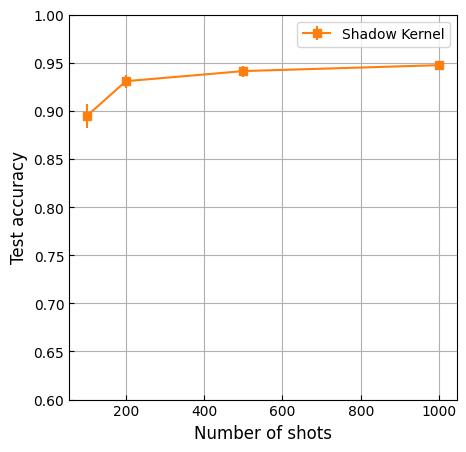

In [12]:
filename = f'results/SK_Tdep_normalize.npy'
sk = np.load(filename)

plt.figure(figsize=(5,5))
plt.rcParams['xtick.direction'] = 'in'
plt.rcParams['ytick.direction'] = 'in'
plt.xlabel("Number of shots", fontsize=12)
plt.ylabel("Test accuracy", rotation=90, fontsize=12)
plt.ylim(0.6,1.0)

plt.errorbar(sk[0,:], sk[1,:], yerr=sk[2,:], marker="s", color="tab:orange", label="Shadow Kernel")
plt.legend()
plt.grid()